In [1]:
import pandas as pd

# Load the datasets
fear_greed_df = pd.read_csv('/content/fear_greed_index.csv')
historical_trader_df = pd.read_csv('/content/historical_data.csv')

# Display basic info for Fear/Greed data
print('--- Fear/Greed Index Dataset ---')
print(fear_greed_df.info())
display(fear_greed_df.head())

# Display basic info for Historical Trader data
print('\n--- Historical Trader Dataset ---')
print(historical_trader_df.info())
display(historical_trader_df.head())

--- Fear/Greed Index Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


/tmp/ipykernel_27151/2620343270.py:5: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  historical_trader_df = pd.read_csv('/content/historical_data.csv')


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Historical Trader Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181921 entries, 0 to 181920
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           181921 non-null  object 
 1   Coin              181921 non-null  object 
 2   Execution Price   181921 non-null  float64
 3   Size Tokens       181921 non-null  float64
 4   Size USD          181921 non-null  float64
 5   Side              181921 non-null  object 
 6   Timestamp IST     181921 non-null  object 
 7   Start Position    181920 non-null  float64
 8   Direction         181920 non-null  object 
 9   Closed PnL        181920 non-null  float64
 10  Transaction Hash  181920 non-null  object 
 11  Order ID          181920 non-null  float64
 12  Crossed           181920 non-null  object 
 13  Fee               181920 non-null  float64
 14  Trade ID          181920 non-null  float64
 15  Timestamp         181920 non-null

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


/tmp/ipykernel_27151/434859522.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x='classification', y='trade_count', data=merged_df, estimator='mean', palette='magma')


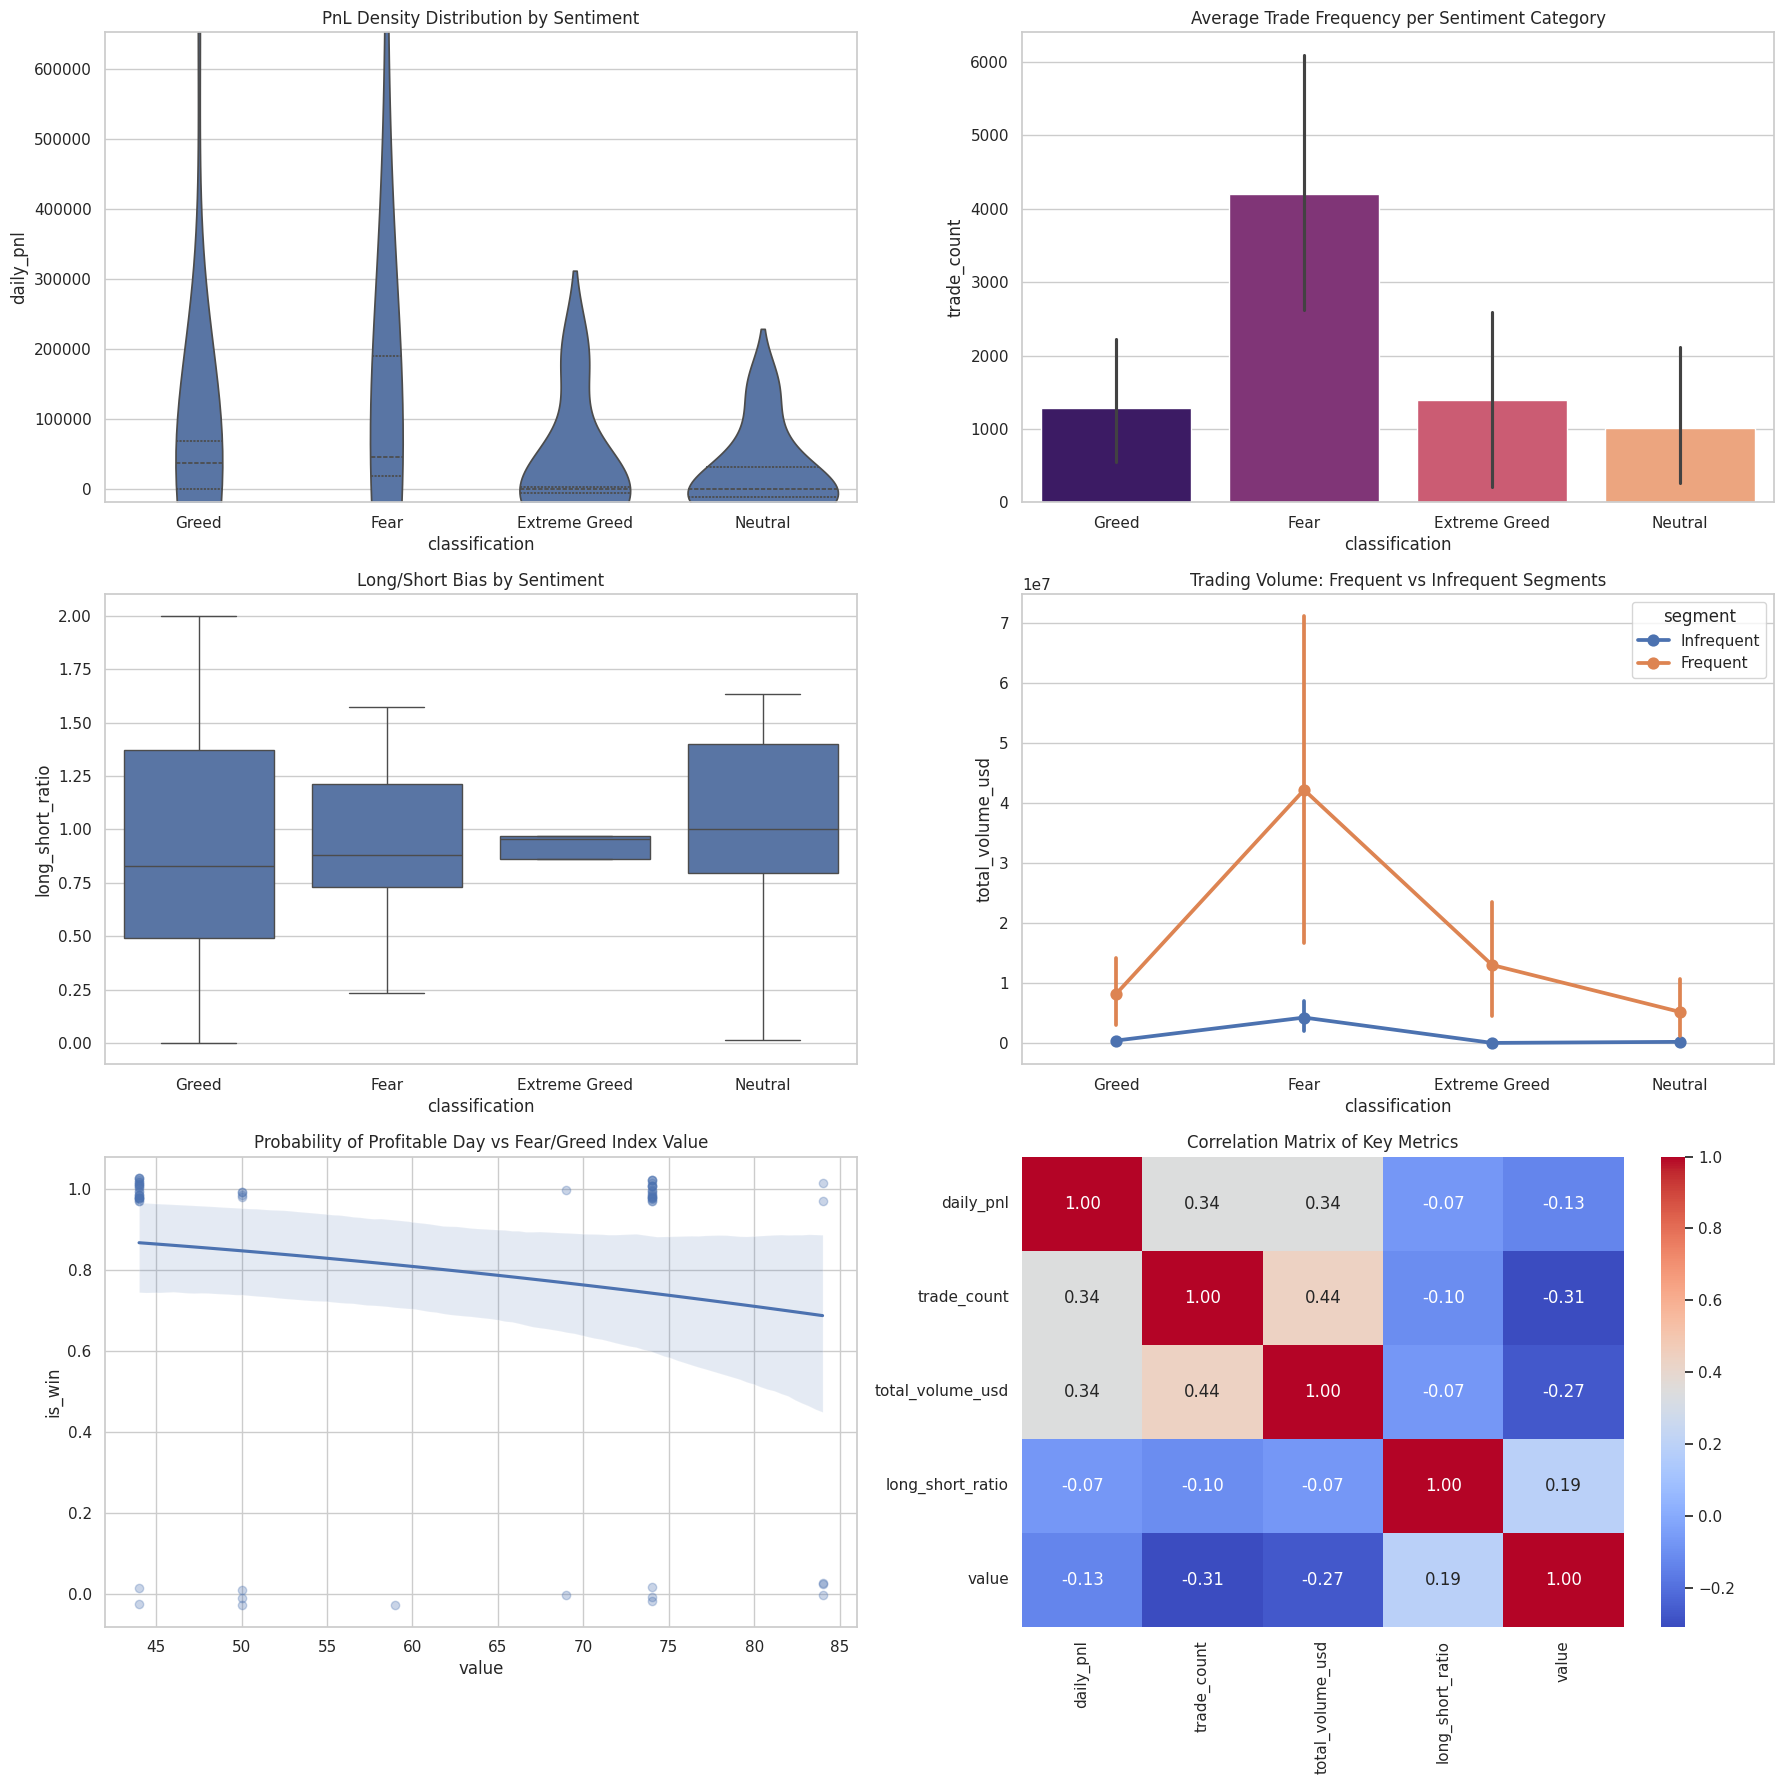

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# 1. PnL by Sentiment (Violin Plot to see density)
sns.violinplot(ax=axes[0, 0], x='classification', y='daily_pnl', data=merged_df, inner='quartile')
axes[0, 0].set_title('PnL Density Distribution by Sentiment')
axes[0, 0].set_ylim(merged_df['daily_pnl'].quantile(0.05), merged_df['daily_pnl'].quantile(0.95))

# 2. Trade Count vs Sentiment
sns.barplot(ax=axes[0, 1], x='classification', y='trade_count', data=merged_df, estimator='mean', palette='magma')
axes[0, 1].set_title('Average Trade Frequency per Sentiment Category')

# 3. Long/Short Ratio per Sentiment
sns.boxplot(ax=axes[1, 0], x='classification', y='long_short_ratio', data=merged_df, showfliers=False)
axes[1, 0].set_title('Long/Short Bias by Sentiment')

# 4. Volume vs Sentiment for different Segments
sns.pointplot(ax=axes[1, 1], x='classification', y='total_volume_usd', hue='segment', data=merged_df)
axes[1, 1].set_title('Trading Volume: Frequent vs Infrequent Segments')

# 5. Win Rate Trend (Over Value of Fear/Greed Index)
sns.regplot(ax=axes[2, 0], x='value', y='is_win', data=merged_df, logistic=True, y_jitter=.03, scatter_kws={'alpha':0.3})
axes[2, 0].set_title('Probability of Profitable Day vs Fear/Greed Index Value')

# 6. Correlation Heatmap of Metrics
corr = merged_df[['daily_pnl', 'trade_count', 'total_volume_usd', 'long_short_ratio', 'value']].corr()
sns.heatmap(ax=axes[2, 1], annot=True, data=corr, cmap='coolwarm', fmt='.2f')
axes[2, 1].set_title('Correlation Matrix of Key Metrics')

plt.tight_layout()
plt.show()

--- Predictive Model: Profitability Bucket (Win/Loss) ---
Accuracy: 0.65

Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00         7
        True       0.65      1.00      0.79        13

    accuracy                           0.65        20
   macro avg       0.33      0.50      0.39        20
weighted avg       0.42      0.65      0.51        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_27151/3879309258.py:29: FutureWarn

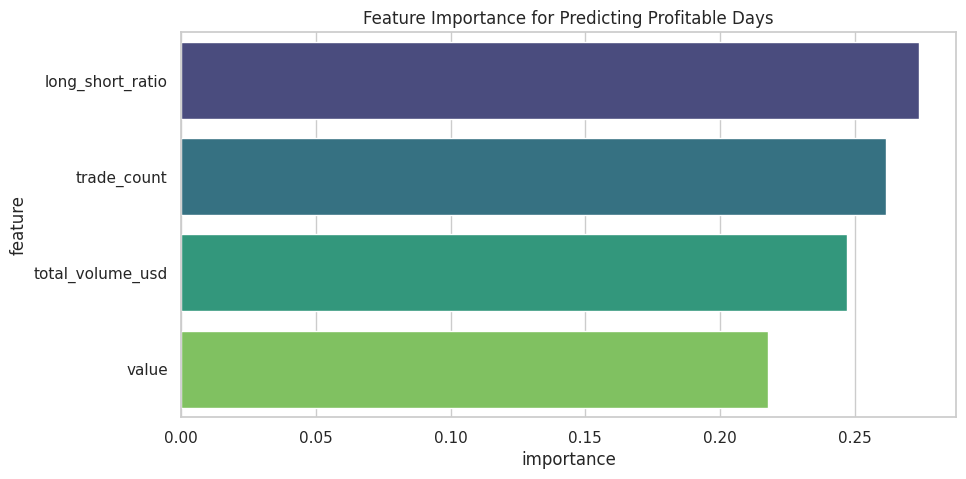

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Feature Selection
# We use behavioral metrics + sentiment value to predict 'is_win'
features = ['trade_count', 'total_volume_usd', 'long_short_ratio', 'value']
X = merged_df[features]
y = merged_df['is_win']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Evaluation
y_pred = model.predict(X_test)
print('--- Predictive Model: Profitability Bucket (Win/Loss) ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# 5. Feature Importance
importances = pd.DataFrame({'feature': features, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('Feature Importance for Predicting Profitable Days')
plt.show()

In [3]:
import pandas as pd

# 1. Clean Trader Data
# Drop the very few rows with nulls (likely incomplete final records)
historical_trader_df.dropna(subset=['Timestamp', 'Direction', 'Closed PnL'], inplace=True)

# 2. Convert Timestamps to Date
# Fear/Greed date is already a string, converting to datetime
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# Historical Trader Data: 'Timestamp' seems to be in milliseconds
historical_trader_df['date'] = pd.to_datetime(historical_trader_df['Timestamp'], unit='ms').dt.normalize()

# 3. Aggregate Daily Metrics per Account
daily_trader_metrics = historical_trader_df.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    total_volume_usd=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    buy_count=('Side', lambda x: (x == 'BUY').sum()),
    sell_count=('Side', lambda x: (x == 'SELL').sum())
).reset_index()

# Calculate Long/Short Ratio (avoid division by zero)
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics['buy_count'] / daily_trader_metrics['sell_count'].replace(0, 1)

# 4. Merge with Sentiment Data
# Merge sentiment into our trader metrics
merged_df = pd.merge(daily_trader_metrics, fear_greed_df[['date', 'value', 'classification']], on='date', how='inner')

print('Alignment Complete.')
print(f'Merged records: {len(merged_df)}')
display(merged_df.head())

Alignment Complete.
Merged records: 66


,Account,date,daily_pnl,trade_count,total_volume_usd,avg_trade_size,buy_count,sell_count,long_short_ratio,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,462,6842632.02,14810.891818,139,323,0.430341,74,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,3356,54854631.95,16345.241940,1572,1784,0.881166,44,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,320,797679.97,2492.749906,145,175,0.828571,74,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,3533,5982611.50,1693.351684,1528,2005,0.762095,44,Fear
4,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,2024-10-27,1.218804e+05,6472,3129795.22,483.590114,3086,3386,0.911400,74,Greed


--- Performance by Sentiment ---


,Classification,Avg_PnL,Median_PnL,Std_PnL,Avg_Trades,Avg_Volume,Win_Rate
0,Extreme Greed,35393.098355,0.000000,85325.499902,1392.400000,7.881354e+06,0.400000
1,Fear,203631.499320,46257.358187,404746.517457,4203.703704,2.258000e+07,0.925926
2,Greed,102919.784075,36993.371011,303701.255130,1287.518519,3.941698e+06,0.814815
3,Neutral,22677.625440,0.162720,61203.360346,1019.428571,3.116126e+06,0.571429


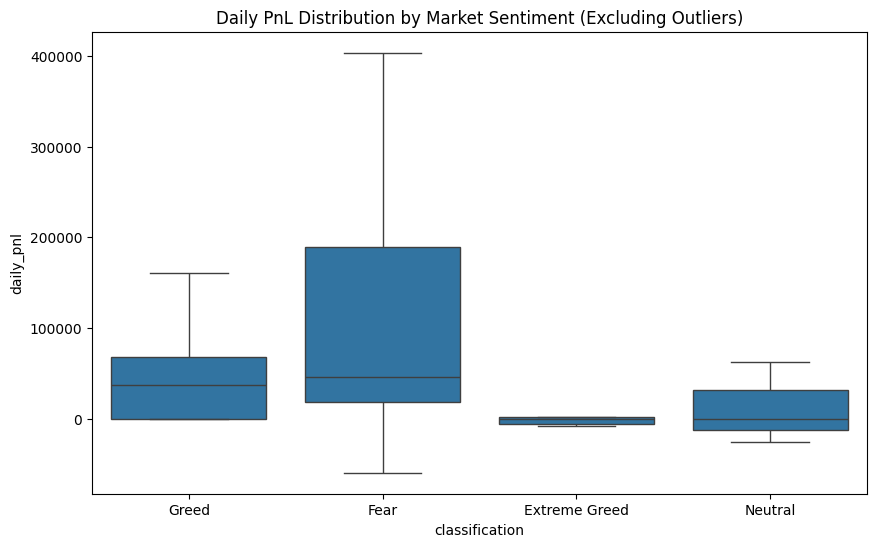


--- Avg PnL: Segment vs Sentiment ---


/tmp/ipykernel_27151/3601466952.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_insight = merged_df.groupby(['segment', 'classification'])['daily_pnl'].mean().unstack()


classification,Extreme Greed,Fear,Greed,Neutral
segment,,,,
Infrequent,-2782.008070,75055.583274,36701.835629,43757.899141
Frequent,60843.169305,342097.870446,185692.219633,6867.420164


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Win Rate per Account/Day (approximate as % of positive daily PnL records)
merged_df['is_win'] = merged_df['daily_pnl'] > 0

# 2. Performance Comparison by Sentiment Classification
sentiment_perf = merged_df.groupby('classification').agg({
    'daily_pnl': ['mean', 'median', 'std'],
    'trade_count': 'mean',
    'total_volume_usd': 'mean',
    'is_win': 'mean'
}).reset_index()

sentiment_perf.columns = ['Classification', 'Avg_PnL', 'Median_PnL', 'Std_PnL', 'Avg_Trades', 'Avg_Volume', 'Win_Rate']

print('--- Performance by Sentiment ---')
display(sentiment_perf)

# 3. Visualization: PnL Distribution by Sentiment
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='daily_pnl', data=merged_df, showfliers=False)
plt.title('Daily PnL Distribution by Market Sentiment (Excluding Outliers)')
plt.show()

# 4. Trader Segmentation
# Frequent vs Infrequent
trader_activity = merged_df.groupby('Account')['trade_count'].mean().reset_index()
trader_activity['segment'] = pd.qcut(trader_activity['trade_count'], q=2, labels=['Infrequent', 'Frequent'])

merged_df = pd.merge(merged_df, trader_activity[['Account', 'segment']], on='Account')

# 5. Segmented Insights
segment_insight = merged_df.groupby(['segment', 'classification'])['daily_pnl'].mean().unstack()
print('\n--- Avg PnL: Segment vs Sentiment ---')
display(segment_insight)

In [2]:
# Check for missing values and duplicates
print('Missing values in Fear/Greed:', fear_greed_df.isnull().sum().sum())
print('Duplicates in Fear/Greed:', fear_greed_df.duplicated().sum())

print('\nMissing values in Trader Data:', historical_trader_df.isnull().sum().sum())
print('Duplicates in Trader Data:', historical_trader_df.duplicated().sum())

Missing values in Fear/Greed: 0
Duplicates in Fear/Greed: 0

Missing values in Trader Data: 9
Duplicates in Trader Data: 0
